<a href="https://colab.research.google.com/github/iankurbhatt/AI-Data-Analyst-Agent/blob/main/database_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [61]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

Database Setup
Create Database Connection

In [62]:
connection = sqlite3.connect("business.db")
cursor = connection.cursor()

Create Customers Table

In [63]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY,
    customer_name TEXT,
    city TEXT
)
""")

Create Products Table

In [64]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price REAL
)
""")

Create Orders Table

In [65]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    order_date TEXT
)
""")

Save changes

In [70]:
connection.commit()

Verify Tables

In [71]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
""")

print(cursor.fetchall())

[('customers',), ('products',), ('orders',)]


Insert Sample Data
Insert Customers

In [72]:
customers = [
    (1, "Ankur", "Gurugram"),
    (2, "Rahul", "Delhi"),
    (3, "Priya", "Mumbai"),
    (4, "Neha", "Bengaluru"),
    (5, "Amit", "Pune")
]

cursor.executemany("""
INSERT OR REPLACE INTO customers
VALUES (?, ?, ?)
""", customers)

Insert Products

In [73]:
products = [
    (101, "Laptop", "Electronics", 70000),
    (102, "Mobile Phone", "Electronics", 30000),
    (103, "Headphones", "Accessories", 2000),
    (104, "Office Chair", "Furniture", 8000),
    (105, "Water Bottle", "Lifestyle", 500)
]

cursor.executemany("""
INSERT OR REPLACE INTO products
VALUES (?, ?, ?, ?)
""", products)

Insert Orders

In [74]:
orders = [
    (1001, 1, 101, 1, "2026-06-01"),
    (1002, 2, 102, 2, "2026-06-03"),
    (1003, 3, 103, 3, "2026-06-05"),
    (1004, 1, 104, 1, "2026-06-10"),
    (1005, 5, 101, 1, "2026-06-15"),
    (1006, 4, 105, 5, "2026-06-20")
]

cursor.executemany("""
INSERT OR REPLACE INTO orders
VALUES (?, ?, ?, ?, ?)
""", orders)

Commit Data

In [75]:
connection.commit()

Verify Data

In [76]:
print("Customers")
cursor.execute("SELECT * FROM customers")
print(cursor.fetchall())

print("\nProducts")
cursor.execute("SELECT * FROM products")
print(cursor.fetchall())

print("\nOrders")
cursor.execute("SELECT * FROM orders")
print(cursor.fetchall())

Customers
[(1, 'Ankur', 'Gurugram'), (2, 'Rahul', 'Delhi'), (3, 'Priya', 'Mumbai'), (4, 'Neha', 'Bengaluru'), (5, 'Amit', 'Pune')]

Products
[(101, 'Laptop', 'Electronics', 70000.0), (102, 'Mobile Phone', 'Electronics', 30000.0), (103, 'Headphones', 'Accessories', 2000.0), (104, 'Office Chair', 'Furniture', 8000.0), (105, 'Water Bottle', 'Lifestyle', 500.0)]

Orders
[(1001, 1, 101, 1, '2026-06-01'), (1002, 2, 102, 2, '2026-06-03'), (1003, 3, 103, 3, '2026-06-05'), (1004, 1, 104, 1, '2026-06-10'), (1005, 5, 101, 1, '2026-06-15'), (1006, 4, 105, 5, '2026-06-20')]


SQL Analysis
Show All Orders

In [77]:
cursor.execute("""
SELECT *
FROM orders
""")

print(cursor.fetchall())

[(1001, 1, 101, 1, '2026-06-01'), (1002, 2, 102, 2, '2026-06-03'), (1003, 3, 103, 3, '2026-06-05'), (1004, 1, 104, 1, '2026-06-10'), (1005, 5, 101, 1, '2026-06-15'), (1006, 4, 105, 5, '2026-06-20')]


Customer Names and Cities

In [78]:
cursor.execute("""
SELECT customer_name, city
FROM customers
""")

print(cursor.fetchall())

[('Ankur', 'Gurugram'), ('Rahul', 'Delhi'), ('Priya', 'Mumbai'), ('Neha', 'Bengaluru'), ('Amit', 'Pune')]


Customers from Delhi

In [79]:
cursor.execute("""
SELECT *
FROM customers
WHERE city='Delhi'
""")

print(cursor.fetchall())

[(2, 'Rahul', 'Delhi')]


Products Sorted by Price

In [80]:
cursor.execute("""
SELECT *
FROM products
ORDER BY price DESC
""")

print(cursor.fetchall())

[(101, 'Laptop', 'Electronics', 70000.0), (102, 'Mobile Phone', 'Electronics', 30000.0), (104, 'Office Chair', 'Furniture', 8000.0), (103, 'Headphones', 'Accessories', 2000.0), (105, 'Water Bottle', 'Lifestyle', 500.0)]


Total Customers

In [81]:
cursor.execute("""
SELECT COUNT(*)
FROM customers
""")

print(cursor.fetchall())

[(5,)]


Total Quantity Sold

In [82]:
cursor.execute("""
SELECT SUM(quantity)
FROM orders
""")

print(cursor.fetchall())

[(13,)]


Customer Purchase Report

In [83]:
cursor.execute("""
SELECT
    customers.customer_name,
    products.product_name,
    orders.quantity,
    orders.order_date

FROM orders

JOIN customers
ON orders.customer_id = customers.customer_id

JOIN products
ON orders.product_id = products.product_id
""")

for row in cursor.fetchall():
    print(row)

('Ankur', 'Laptop', 1, '2026-06-01')
('Rahul', 'Mobile Phone', 2, '2026-06-03')
('Priya', 'Headphones', 3, '2026-06-05')
('Ankur', 'Office Chair', 1, '2026-06-10')
('Amit', 'Laptop', 1, '2026-06-15')
('Neha', 'Water Bottle', 5, '2026-06-20')


Top Selling Products

In [84]:
cursor.execute("""
SELECT
    products.product_name,
    SUM(orders.quantity) AS total_units_sold

FROM orders

JOIN products
ON orders.product_id = products.product_id

GROUP BY products.product_name

ORDER BY total_units_sold DESC
""")

print(cursor.fetchall())

[('Water Bottle', 5), ('Headphones', 3), ('Mobile Phone', 2), ('Laptop', 2), ('Office Chair', 1)]


Load Data into Pandas

In [85]:
customers_df = pd.read_sql(
    "SELECT * FROM customers",
    connection
)

customers_df

,customer_id,customer_name,city
0,1,Ankur,Gurugram
1,2,Rahul,Delhi
2,3,Priya,Mumbai
3,4,Neha,Bengaluru
4,5,Amit,Pune


Products DataFrame

In [86]:
products_df = pd.read_sql(
    "SELECT * FROM products",
    connection
)

products_df

,product_id,product_name,category,price
0,101,Laptop,Electronics,70000.0
1,102,Mobile Phone,Electronics,30000.0
2,103,Headphones,Accessories,2000.0
3,104,Office Chair,Furniture,8000.0
4,105,Water Bottle,Lifestyle,500.0


Most Expensive Products

In [87]:
products_df.sort_values(
    by="price",
    ascending=False
)

,product_id,product_name,category,price
0,101,Laptop,Electronics,70000.0
1,102,Mobile Phone,Electronics,30000.0
3,104,Office Chair,Furniture,8000.0
2,103,Headphones,Accessories,2000.0
4,105,Water Bottle,Lifestyle,500.0


Electronics Products

In [88]:
products_df[
    products_df["category"] == "Electronics"
]

,product_id,product_name,category,price
0,101,Laptop,Electronics,70000.0
1,102,Mobile Phone,Electronics,30000.0


Sales DataFrame

In [89]:
sales_df = pd.read_sql("""
SELECT
    customers.customer_name,
    products.product_name,
    products.price,
    orders.quantity,
    orders.order_date

FROM orders

JOIN customers
ON orders.customer_id = customers.customer_id

JOIN products
ON orders.product_id = products.product_id
""", connection)

sales_df

,customer_name,product_name,price,quantity,order_date
0,Ankur,Laptop,70000.0,1,2026-06-01
1,Rahul,Mobile Phone,30000.0,2,2026-06-03
2,Priya,Headphones,2000.0,3,2026-06-05
3,Ankur,Office Chair,8000.0,1,2026-06-10
4,Amit,Laptop,70000.0,1,2026-06-15
5,Neha,Water Bottle,500.0,5,2026-06-20


Revenue Calculation
Create Revenue Column

In [90]:
sales_df["revenue"] = (
    sales_df["price"] *
    sales_df["quantity"]
)

sales_df

,customer_name,product_name,price,quantity,order_date,revenue
0,Ankur,Laptop,70000.0,1,2026-06-01,70000.0
1,Rahul,Mobile Phone,30000.0,2,2026-06-03,60000.0
2,Priya,Headphones,2000.0,3,2026-06-05,6000.0
3,Ankur,Office Chair,8000.0,1,2026-06-10,8000.0
4,Amit,Laptop,70000.0,1,2026-06-15,70000.0
5,Neha,Water Bottle,500.0,5,2026-06-20,2500.0


Total Revenue

In [91]:
total_revenue = sales_df["revenue"].sum()

print(f"Total Revenue = ₹{total_revenue:,.0f}")

Total Revenue = ₹216,500


Revenue by Product

In [92]:
product_revenue = (
    sales_df.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

,revenue
product_name,
Laptop,140000.0
Mobile Phone,60000.0
Office Chair,8000.0
Headphones,6000.0
Water Bottle,2500.0


Revenue Chart

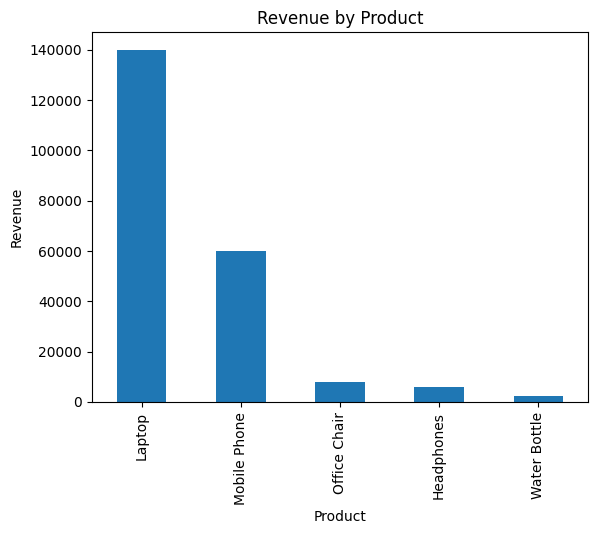

In [93]:
product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

Quantity Chart

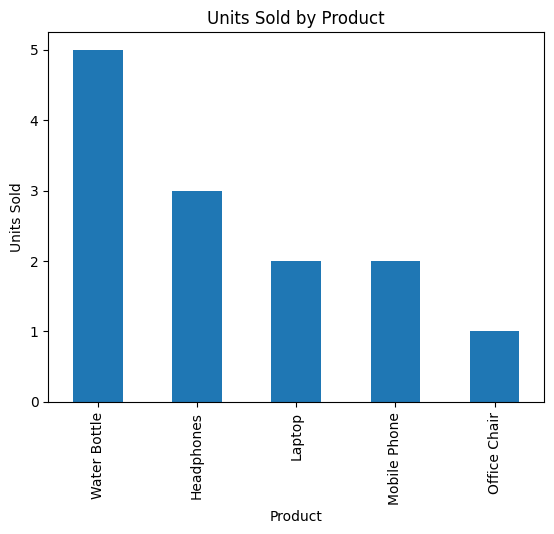

In [94]:
product_quantity = (
    sales_df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.plot(kind="bar")

plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.show()

Customer Chart

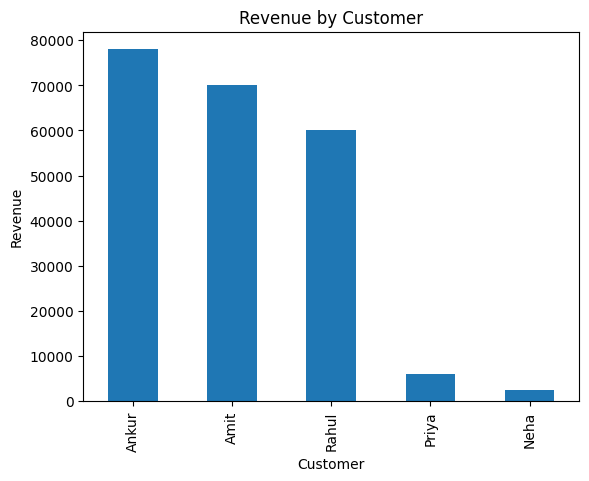

In [95]:
customer_revenue = (
    sales_df.groupby("customer_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.plot(kind="bar")

plt.title("Revenue by Customer")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

Insights

In [96]:
print("===== BUSINESS INSIGHTS =====\n")

top_product = product_revenue.idxmax()
top_product_revenue = product_revenue.max()

top_customer = customer_revenue.idxmax()
top_customer_revenue = customer_revenue.max()

print(f"Total Revenue Generated: ₹{total_revenue:,.0f}")

print(
    f"Highest Revenue Product: {top_product}"
    f" (₹{top_product_revenue:,.0f})"
)

print(
    f"Highest Revenue Customer: {top_customer}"
    f" (₹{top_customer_revenue:,.0f})"
)

===== BUSINESS INSIGHTS =====

Total Revenue Generated: ₹216,500
Highest Revenue Product: Laptop (₹140,000)
Highest Revenue Customer: Ankur (₹78,000)


Close Connection

In [97]:
connection.close()